# Signal analysis for 50 Rn-222 repetitions

This notebook reproduces the analyses behind the plots used in `AOCMP 2026 - Gamma_detection_poster_CDeSio.pdf`, using the 50-repetition run folder:

`rn222_repetition_runs/rn222_2mmfully_50reps_10k`

Scope and narrative:

1. Load every completed repetition listed in the 50-repetition manifest and report missing outputs while the run is still populating.
2. Show baseline-subtracted detector profiles for all simulated source states. This is the context plot: it includes both broad diffusion and localised secondary-source cases.
3. Estimate diffusion fraction only for the baseline/diffuse family (`baseline`, `diff10`, `diff50`, `diff90`). Localised-source cases are a different physical hypothesis and are not reported as diffusion estimates.
4. Keep the far-side leakage ROI as a separate visual diagnostic.
5. Use the overlapping/displaced-source ROI (`250 <= z <= 750 mm`) inside the localised-source search and residual-position section.
6. Compute cumulative time-window detectability from whole profile residuals with no ROI definition, then plot every available case so the poster example can be chosen later.


In [37]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns', 140)
pd.set_option('display.max_colwidth', None)

figure_output_dir = Path('figures') / 'signal_analysis_50reps'
metrics_output_dir = Path('outputs') / 'signal_analysis_50reps'
figure_output_dir.mkdir(parents=True, exist_ok=True)
metrics_output_dir.mkdir(parents=True, exist_ok=True)


def save_figure(fig, name):
    safe_name = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(name)).strip('_')
    path = figure_output_dir / f'{safe_name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved figure: {path}')
    return path


def sem(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) <= 1:
        return 0.0
    return float(values.std(ddof=1) / np.sqrt(len(values)))


## Configuration

The 50-repetition manifest uses absolute output stems, so the notebook can be run while the folder is still filling. Missing candidate outputs are skipped and listed rather than treated as fatal. The baseline must be available before the downstream analyses can run.


In [38]:
repetition_run_dir = Path('rn222_repetition_runs/rn222_2mmfully_50reps_10k')
generated_files_log = repetition_run_dir / 'generated_files_log.tsv'

analysis_cases = {
    'baseline': {
        'label': 'No diffusion baseline',
        'diffusion_fraction': 0.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'diff10': {
        'label': 'Source diffusion 10%',
        'diffusion_fraction': 10.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'diff50': {
        'label': 'Source diffusion 50%',
        'diffusion_fraction': 50.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'diff90': {
        'label': 'Source diffusion 90%',
        'diffusion_fraction': 90.0,
        'secondary_present': 0,
        'secondary_fraction': 0.0,
        'secondary_z_mm': np.nan,
    },
    'loc20': {
        'label': 'Localised secondary 20%',
        'diffusion_fraction': np.nan,
        'secondary_present': 1,
        'secondary_fraction': 20.0,
        'secondary_z_mm': 500.0,
    },
    'loc40': {
        'label': 'Localised secondary 40%',
        'diffusion_fraction': np.nan,
        'secondary_present': 1,
        'secondary_fraction': 40.0,
        'secondary_z_mm': 500.0,
    },
    'loc60': {
        'label': 'Localised secondary 60%',
        'diffusion_fraction': np.nan,
        'secondary_present': 1,
        'secondary_fraction': 60.0,
        'secondary_z_mm': 500.0,
    },
}

case_order = ['baseline', 'diff10', 'diff50', 'diff90', 'loc20', 'loc40', 'loc60']
candidate_order = [key for key in case_order if key != 'baseline']
diffusion_training_cases = ['baseline', 'diff10', 'diff50', 'diff90']
secondary_training_cases = case_order
case_labels = {key: meta['label'] for key, meta in analysis_cases.items()}

panel_sets = {
    'PosY': ['physPhotonDetectorPosY'],
    'NegY': ['physPhotonDetectorNegY'],
    'PosX': ['physPhotonDetectorPosX'],
    'NegX': ['physPhotonDetectorNegX'],
    'Ysum': ['physPhotonDetectorPosY', 'physPhotonDetectorNegY'],
    'Xsum': ['physPhotonDetectorPosX', 'physPhotonDetectorNegX'],
    'All': ['physPhotonDetectorPosY', 'physPhotonDetectorNegY', 'physPhotonDetectorPosX', 'physPhotonDetectorNegX'],
}
all_detector_panels = panel_sets['All']

z_bins = np.linspace(-1000, 1000, 81)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
central_z_roi_mm = (-150.0, 150.0)
leakage_roi_z_mm = (-750.0, -550.0)
secondary_search_z_roi_mm = (250.0, 750.0)

# Poster profile/time analyses use activity-normalized expected detections.
rn222_half_life_days = 3.8235
source_activity_uCi = 3.0
source_activity_Bq = source_activity_uCi * 3.7e4
rn222_lambda_s = np.log(2) / (rn222_half_life_days * 24 * 3600)
rn222_initial_atoms = source_activity_Bq / rn222_lambda_s

profile_time_limit_s = 1e7
time_thresholds = [
    ('15 min', 15 * 60),
    ('30 min', 30 * 60),
    ('1 h', 1 * 3600),
    ('2 h', 2 * 3600),
    ('6 h', 6 * 3600),
    ('1 d', 1 * 24 * 3600),
    ('2 d', 2 * 24 * 3600),
]

display(pd.DataFrame([{
    'repetition_run_dir': str(repetition_run_dir),
    'manifest': str(generated_files_log),
    'source_activity_uCi': source_activity_uCi,
    'source_activity_Bq': source_activity_Bq,
    'rn222_initial_atoms': rn222_initial_atoms,
    'profile_time_limit_s': profile_time_limit_s,
    'central_z_roi_mm': central_z_roi_mm,
    'leakage_roi_z_mm': leakage_roi_z_mm,
    'secondary_search_z_roi_mm': secondary_search_z_roi_mm,
}]))


,repetition_run_dir,manifest,source_activity_uCi,source_activity_Bq,rn222_initial_atoms,profile_time_limit_s,central_z_roi_mm,leakage_roi_z_mm,secondary_search_z_roi_mm
0,rn222_repetition_runs/rn222_2mmfully_50reps_10k,rn222_repetition_runs/rn222_2mmfully_50reps_10k/generated_files_log.tsv,3.0,111000.0,5.290203e+10,10000000.0,"(-150.0, 150.0)","(-750.0, -550.0)","(250.0, 750.0)"


## Load completed repetitions

Only photon boundary files that already exist are loaded. Re-run this cell as the batch job progresses; the downstream plots will update automatically once candidate cases appear.


In [39]:
def output_csv_from_stem(output_stem):
    return Path(f'{output_stem}_photon_boundaries.csv')


def load_repetition(path, case_key, rep):
    usecols = ['eventID', 'particleName', 'boundary', 'volumeName', 'x_mm', 'y_mm', 'z_mm', 'time_s', 'kineticEnergy_MeV']
    df = pd.read_csv(path, usecols=usecols)
    entries = df[
        (df['particleName'] == 'gamma')
        & (df['boundary'] == 'enter')
        & (df['volumeName'].isin(all_detector_panels))
    ].copy()
    return {
        'case': case_key,
        'rep': int(rep),
        'path': str(path),
        'entries': entries,
        'n_events': int(df['eventID'].nunique()),
    }


def load_repetition_cases():
    if not generated_files_log.exists():
        raise FileNotFoundError(f'Missing manifest: {generated_files_log}')
    log_df = pd.read_csv(generated_files_log, sep='\t')
    reps_by_case = {key: [] for key in analysis_cases}
    skipped = []
    for row in log_df.itertuples(index=False):
        if row.case not in reps_by_case:
            continue
        csv_path = output_csv_from_stem(row.output_stem)
        if not csv_path.exists():
            skipped.append({'case': row.case, 'rep': int(row.rep), 'expected_csv': str(csv_path)})
            continue
        reps_by_case[row.case].append(load_repetition(csv_path, row.case, row.rep))
    loaded = {case: sorted(reps, key=lambda rep: rep['rep']) for case, reps in reps_by_case.items() if reps}
    return loaded, pd.DataFrame(skipped)


def print_repetition_summary(cases, skipped_df):
    rows = []
    for key in case_order:
        reps = cases.get(key, [])
        rows.append({
            'case': key,
            'label': case_labels[key],
            'loaded_repetitions': len(reps),
            'loaded_rep_ids': [rep['rep'] for rep in reps],
            'detector_entries': sum(len(rep['entries']) for rep in reps),
        })
    summary = pd.DataFrame(rows)
    display(summary)
    if not skipped_df.empty:
        print(f'Missing expected photon-boundary outputs: {len(skipped_df)}')
        display(skipped_df.groupby('case').size().rename('missing').reset_index())
        display(skipped_df.head(12))
    return summary

cases, skipped_repetitions_df = load_repetition_cases()
load_summary_df = print_repetition_summary(cases, skipped_repetitions_df)
load_summary_df.to_csv(metrics_output_dir / 'loaded_repetition_summary.csv', index=False)
skipped_repetitions_df.to_csv(metrics_output_dir / 'missing_expected_outputs.csv', index=False)

if 'baseline' not in cases:
    raise RuntimeError('No baseline repetitions are available yet. Wait for baseline photon-boundary files, then rerun.')

candidate_keys_available = [key for key in candidate_order if key in cases]
diffusion_cases_available = [key for key in diffusion_training_cases if key in cases]
print('Available candidates:', candidate_keys_available)


,case,label,loaded_repetitions,loaded_rep_ids,detector_entries
0,baseline,No diffusion baseline,50,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]",624807
1,diff10,Source diffusion 10%,50,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]",618990
2,diff50,Source diffusion 50%,50,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]",600473
3,diff90,Source diffusion 90%,50,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]",580695
4,loc20,Localised secondary 20%,50,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]",614297
5,loc40,Localised secondary 40%,50,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]",602215
6,loc60,Localised secondary 60%,50,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]",593690


Available candidates: ['diff10', 'diff50', 'diff90', 'loc20', 'loc40', 'loc60']


## Shared signal helpers

These helpers compute raw rates, activity-scaled expected detections, baseline-subtracted residual profiles, and the per-repetition features used by the diffusion and localised-source analyses.


In [40]:
def select_entries(rep, panels, time_limit_s=None):
    selected = rep['entries'][rep['entries']['volumeName'].isin(panels)]
    if time_limit_s is not None:
        selected = selected[selected['time_s'].notna() & (selected['time_s'] <= time_limit_s)]
    return selected


def hist_counts(rep, panels, bins=z_bins, coord='z_mm', time_limit_s=None):
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    return np.histogram(selected[coord], bins=bins)[0].astype(float)


def event_normalized_profiles(case_key, panels, time_limit_s=None):
    return np.vstack([
        hist_counts(rep, panels, time_limit_s=time_limit_s) / rep['n_events']
        for rep in cases[case_key]
    ])


def activity_scaled_profiles(case_key, panels, time_limit_s=None):
    rows = []
    for rep in cases[case_key]:
        scale = rn222_initial_atoms / rep['n_events']
        rows.append(hist_counts(rep, panels, time_limit_s=time_limit_s) * scale)
    return np.vstack(rows)


def profile_mean_sem(profile_stack):
    profile_stack = np.asarray(profile_stack, dtype=float)
    mean = profile_stack.mean(axis=0)
    if len(profile_stack) > 1:
        err = profile_stack.std(axis=0, ddof=1) / np.sqrt(len(profile_stack))
    else:
        err = np.zeros_like(mean)
    return mean, err


def activity_residual(candidate_key, panels, time_limit_s=None):
    base = activity_scaled_profiles('baseline', panels, time_limit_s=time_limit_s)
    cand = activity_scaled_profiles(candidate_key, panels, time_limit_s=time_limit_s)
    base_mean, base_sem = profile_mean_sem(base)
    cand_mean, cand_sem = profile_mean_sem(cand)
    residual = cand_mean - base_mean
    sigma = np.sqrt(base_sem ** 2 + cand_sem ** 2)
    zscore = np.divide(residual, sigma, out=np.zeros_like(residual), where=sigma > 0)
    return {
        'baseline_mean': base_mean,
        'candidate_mean': cand_mean,
        'residual': residual,
        'sigma': sigma,
        'zscore': zscore,
        'baseline_stack': base,
        'candidate_stack': cand,
    }


def weighted_mean_std(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total <= 0:
        return np.nan, np.nan
    mean = float(np.sum(values * weights) / total)
    var = float(np.sum(weights * (values - mean) ** 2) / total)
    return mean, np.sqrt(max(var, 0.0))


def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if weights.sum() <= 0:
        return [np.nan for _ in quantiles]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights) / weights.sum()
    return np.interp(quantiles, cdf, values)


def positive_weighted_position(centers, residual):
    positive = np.clip(np.asarray(residual, dtype=float), 0, None)
    total = positive.sum()
    if total <= 0:
        return np.nan
    return float(np.sum(np.asarray(centers) * positive) / total)


def baseline_mean_profiles():
    profiles = {}
    for view_name, panels in panel_sets.items():
        profiles[view_name] = event_normalized_profiles('baseline', panels).mean(axis=0)
    return profiles

baseline_profiles = baseline_mean_profiles()


In [41]:
def extract_features_for_rep(rep, baseline_profiles):
    row = {
        'case': rep['case'],
        'rep': rep['rep'],
        'label': case_labels[rep['case']],
        'n_events': rep['n_events'],
        'diffusion_fraction_true': analysis_cases[rep['case']]['diffusion_fraction'],
        'secondary_present_true': analysis_cases[rep['case']]['secondary_present'],
        'secondary_fraction_true': analysis_cases[rep['case']]['secondary_fraction'],
        'secondary_z_mm_true': analysis_cases[rep['case']]['secondary_z_mm'],
    }

    all_rate = len(select_entries(rep, panel_sets['All'])) / rep['n_events']
    row['detected_rate_all_per_event'] = all_rate

    for view_name, panels in panel_sets.items():
        counts = hist_counts(rep, panels)
        rate_profile = counts / rep['n_events']
        total_counts = counts.sum()
        total_rate = total_counts / rep['n_events']
        normalized_shape = counts / total_counts if total_counts > 0 else np.zeros_like(counts)

        mean_z, std_z = weighted_mean_std(z_centers, counts)
        q10, q50, q90 = weighted_quantile(z_centers, counts, [0.10, 0.50, 0.90])
        central_mask = (z_centers >= central_z_roi_mm[0]) & (z_centers <= central_z_roi_mm[1])
        secondary_mask = (z_centers >= secondary_search_z_roi_mm[0]) & (z_centers <= secondary_search_z_roi_mm[1])
        leakage_mask = (z_centers >= leakage_roi_z_mm[0]) & (z_centers <= leakage_roi_z_mm[1])
        far_mask = ~central_mask
        residual = rate_profile - baseline_profiles[view_name]
        positive_residual = np.clip(residual, 0, None)

        prefix = f'{view_name}_'
        row[prefix + 'rate_per_event'] = total_rate
        row[prefix + 'fraction_of_all'] = total_rate / all_rate if all_rate > 0 else np.nan
        row[prefix + 'z_mean_mm'] = mean_z
        row[prefix + 'z_std_mm'] = std_z
        row[prefix + 'z_q10_mm'] = q10
        row[prefix + 'z_median_mm'] = q50
        row[prefix + 'z_q90_mm'] = q90
        row[prefix + 'z_q80_width_mm'] = q90 - q10 if np.isfinite(q90) and np.isfinite(q10) else np.nan
        row[prefix + 'central_rate_per_event'] = counts[central_mask].sum() / rep['n_events']
        row[prefix + 'far_rate_per_event'] = counts[far_mask].sum() / rep['n_events']
        row[prefix + 'central_fraction'] = counts[central_mask].sum() / total_counts if total_counts > 0 else np.nan
        row[prefix + 'secondary_roi_rate_per_event'] = counts[secondary_mask].sum() / rep['n_events']
        row[prefix + 'leakage_roi_rate_per_event'] = counts[leakage_mask].sum() / rep['n_events']
        row[prefix + 'residual_l1_per_event'] = np.abs(residual).sum()
        row[prefix + 'positive_residual_per_event'] = positive_residual.sum()
        row[prefix + 'positive_residual_centroid_z_mm'] = positive_weighted_position(z_centers, residual)
        row[prefix + 'positive_residual_peak_z_mm'] = z_centers[np.argmax(residual)] if len(residual) else np.nan
        row[prefix + 'positive_residual_peak_per_event'] = np.max(residual) if len(residual) else np.nan

        for i, value in enumerate(normalized_shape):
            row[f'{prefix}shape_bin_{i:02d}'] = value
        for i, value in enumerate(residual):
            row[f'{prefix}residual_bin_{i:02d}'] = value

    pos_y = row['PosY_rate_per_event']
    neg_y = row['NegY_rate_per_event']
    pos_x = row['PosX_rate_per_event']
    neg_x = row['NegX_rate_per_event']
    row['Y_panel_asymmetry'] = (pos_y - neg_y) / (pos_y + neg_y) if (pos_y + neg_y) > 0 else np.nan
    row['X_panel_asymmetry'] = (pos_x - neg_x) / (pos_x + neg_x) if (pos_x + neg_x) > 0 else np.nan
    row['Y_to_X_rate_ratio'] = row['Ysum_rate_per_event'] / row['Xsum_rate_per_event'] if row['Xsum_rate_per_event'] > 0 else np.nan
    return row

feature_rows = []
for case_key in case_order:
    for rep in cases.get(case_key, []):
        feature_rows.append(extract_features_for_rep(rep, baseline_profiles))
features_df = pd.DataFrame(feature_rows)
features_df.to_csv(metrics_output_dir / 'detector_signal_features.csv', index=False)
print(f'Feature table: {features_df.shape[0]} repetitions x {features_df.shape[1]} columns')
display(features_df[['case', 'rep', 'diffusion_fraction_true', 'secondary_present_true', 'detected_rate_all_per_event', 'All_z_std_mm', 'Xsum_positive_residual_peak_z_mm']].head(12))


Feature table: 350 repetitions x 1258 columns


,case,rep,diffusion_fraction_true,secondary_present_true,detected_rate_all_per_event,All_z_std_mm,Xsum_positive_residual_peak_z_mm
0,baseline,1,0.0,0,1.483451,234.341689,212.5
1,baseline,2,0.0,0,1.489755,233.140888,-262.5
2,baseline,3,0.0,0,1.476882,238.822741,112.5
3,baseline,4,0.0,0,1.495469,236.648496,-362.5
4,baseline,5,0.0,0,1.491862,234.796413,137.5
5,baseline,6,0.0,0,1.490881,235.731104,-87.5
6,baseline,7,0.0,0,1.481032,241.234470,237.5
7,baseline,8,0.0,0,1.488355,235.214929,12.5
8,baseline,9,0.0,0,1.496073,234.683088,112.5
9,baseline,10,0.0,0,1.491293,236.076595,87.5


## 1. Baseline-subtracted profiles for all source states

This is the contextual result plot. It includes both broad diffusion and localised secondary-source cases, because the baseline-subtracted spatial profiles are the evidence that detector position carries source-state information beyond total count rate.


Saved figure: figures/signal_analysis_50reps/poster_01_baseline_subtracted_profiles_xsum_all_cases.png


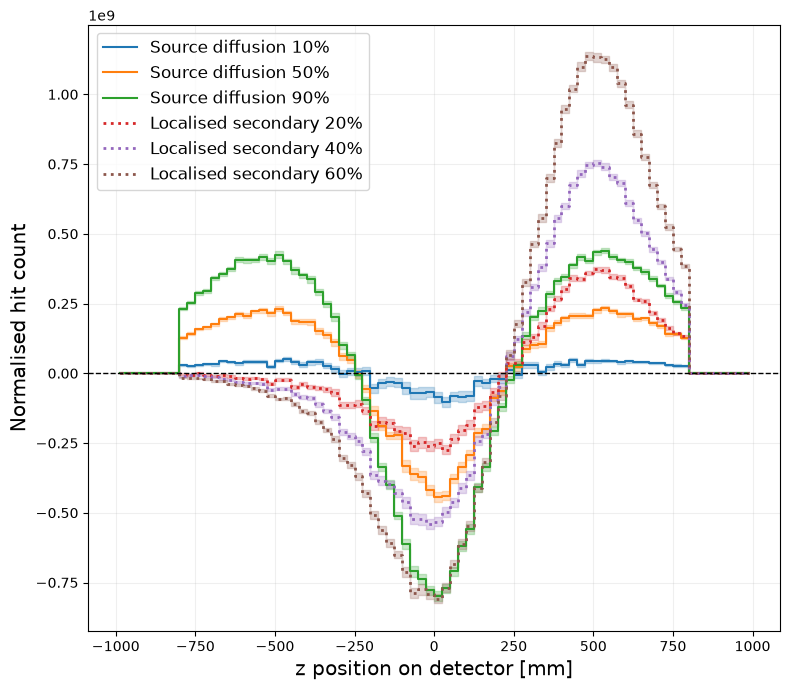

In [60]:
if candidate_keys_available:
    fig, ax = plt.subplots(figsize=(8, 7))
    colors = dict(zip(candidate_order, plt.cm.tab10(np.arange(len(candidate_order)))))
    for key in candidate_keys_available:
        result = activity_residual(key, panel_sets['Xsum'], time_limit_s=profile_time_limit_s)
        residual = result['residual']
        sigma = result['sigma']
        ls = 'dotted' if 'loc' in key else 'solid'
        lw = 2 if 'loc' in key else 1.5
        ax.step(z_centers, residual, where='mid', color=colors[key], linewidth=lw, linestyle=ls, label=case_labels[key])
        ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', color=colors[key], alpha=0.25)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('z position on detector [mm]',fontsize='x-large')
    ax.set_ylabel('Normalised hit count',fontsize='x-large')
    #ax.set_title('PosX + NegX: activity-normalised candidate - baseline', fontsize='x-large')
    ax.grid(alpha=0.20)
    ax.legend(fontsize='large', ncols=1)
    plt.tight_layout()
    save_figure(fig, 'poster_01_baseline_subtracted_profiles_xsum_all_cases')
    plt.show()
else:
    print('No candidate cases are available yet; rerun when candidate outputs exist.')


## 2. Diffusion fraction estimate

The diffusion model is trained and evaluated only on the retained-source and broad-diffusion cases. Localised cases are intentionally excluded from this plot and from the reported diffusion-fraction performance.


LOO MAE: 0.96 percentage points
LOO R^2: 0.999


,case,true_diffusion_fraction,predicted_mean,predicted_sd,predicted_min,predicted_max,n
0,baseline,0.0,0.399070,0.672579,0.000000,2.567980,50
1,diff10,10.0,10.528025,1.204528,8.350315,14.064481,50
2,diff50,50.0,49.488803,1.396080,46.676117,52.295541,50
3,diff90,90.0,90.152789,1.483070,87.346053,93.380235,50


Saved figure: figures/signal_analysis_50reps/poster_02_diffusion_fraction_cv_prediction.png


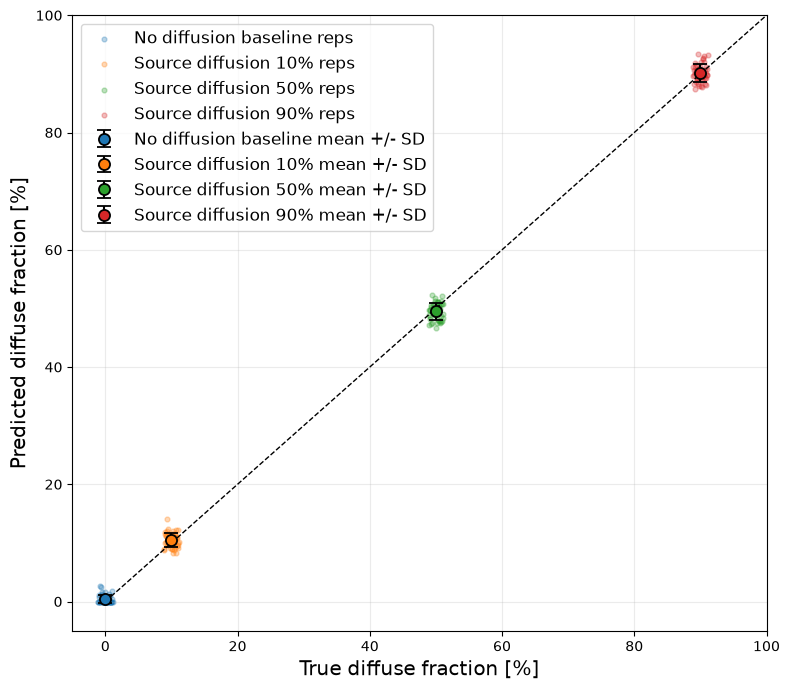

In [72]:
def columns_matching(df, prefixes=(), contains=()):
    cols = []
    for col in df.columns:
        if prefixes and not any(col.startswith(prefix) for prefix in prefixes):
            continue
        if contains and not any(token in col for token in contains):
            continue
        cols.append(col)
    return cols

if set(diffusion_training_cases).issubset(set(features_df['case'])):
    shape_feature_cols = []
    shape_feature_cols += columns_matching(features_df, prefixes=('PosY_', 'NegY_', 'Ysum_', 'Xsum_', 'All_'), contains=('shape_bin_',))
    shape_feature_cols += [
        col for col in features_df.columns
        if any(col.endswith(suffix) for suffix in [
            'z_std_mm', 'z_q80_width_mm', 'central_fraction', 'positive_residual_centroid_z_mm',
            'positive_residual_peak_z_mm', 'residual_l1_per_event'
        ])
    ]
    shape_feature_cols += ['Y_panel_asymmetry', 'X_panel_asymmetry', 'Y_to_X_rate_ratio']
    shape_feature_cols = sorted(set(shape_feature_cols))

    train_diff = features_df[features_df['case'].isin(diffusion_training_cases)].copy()
    X_diff = train_diff[shape_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_diff = train_diff['diffusion_fraction_true'].to_numpy(dtype=float)

    diff_pred = np.zeros(len(train_diff))
    for train_idx, test_idx in LeaveOneOut().split(X_diff):
        model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4, 4, 25)))
        model.fit(X_diff.iloc[train_idx], y_diff[train_idx])
        diff_pred[test_idx] = model.predict(X_diff.iloc[test_idx])

    train_diff['diffusion_fraction_pred_cv'] = np.clip(diff_pred, 0, 100)
    diffusion_summary_df = train_diff.groupby('case', sort=False).agg(
        true_diffusion_fraction=('diffusion_fraction_true', 'first'),
        predicted_mean=('diffusion_fraction_pred_cv', 'mean'),
        predicted_sd=('diffusion_fraction_pred_cv', 'std'),
        predicted_min=('diffusion_fraction_pred_cv', 'min'),
        predicted_max=('diffusion_fraction_pred_cv', 'max'),
        n=('diffusion_fraction_pred_cv', 'size'),
    ).reindex(diffusion_training_cases).reset_index()

    print(f"LOO MAE: {mean_absolute_error(y_diff, train_diff['diffusion_fraction_pred_cv']):.2f} percentage points")
    print(f"LOO R^2: {r2_score(y_diff, train_diff['diffusion_fraction_pred_cv']):.3f}")
    display(diffusion_summary_df)
    train_diff[['case', 'rep', 'diffusion_fraction_true', 'diffusion_fraction_pred_cv']].to_csv(metrics_output_dir / 'diffusion_fraction_cv_predictions.csv', index=False)
    diffusion_summary_df.to_csv(metrics_output_dir / 'diffusion_fraction_cv_summary.csv', index=False)

    fig, ax = plt.subplots(figsize=(8,7))
    case_colors = dict(zip(diffusion_training_cases, plt.cm.tab10(np.arange(len(diffusion_training_cases)))))
    for case_key, group in train_diff.groupby('case', sort=False):
        color = case_colors[case_key]
        x_true = group['diffusion_fraction_true'].iloc[0]
        jitter = np.linspace(-1.1, 1.1, len(group)) if len(group) > 1 else np.array([0.0])
        ax.scatter(x_true + jitter, group['diffusion_fraction_pred_cv'], s=12, alpha=0.3, color=color, label=f'{case_labels[case_key]} reps')
        ax.errorbar(x_true, group['diffusion_fraction_pred_cv'].mean(), yerr=group['diffusion_fraction_pred_cv'].std(), fmt='o', ms=8, color=color, mec='black', mew=1.3, capsize=5, ecolor='black', label=f'{case_labels[case_key]} mean +/- SD')
    ax.plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1)
    ax.set_xlim(-5, 100)
    ax.set_ylim(-5, 100)
    ax.set_xlabel('True diffuse fraction [%]',fontsize='x-large')
    ax.set_ylabel('Predicted diffuse fraction [%]',fontsize='x-large')
    #ax.set_title('Diffusion fraction from detected gamma profile shape', fontsize='x-large')
    ax.grid(alpha=0.25)
    ax.legend(fontsize='large')
    plt.tight_layout()
    save_figure(fig, 'poster_02_diffusion_fraction_cv_prediction')
    plt.show()
else:
    missing = [key for key in diffusion_training_cases if key not in set(features_df['case'])]
    print('Diffusion estimate skipped until these cases are available:', missing)


## 3. Applicator-retained central signal

The central $+y$-panel ROI is used as an applicator-facing signal. Its rate is divided by the mean retained-source baseline rate to give the fraction of detector signal remaining consistent with the applicator region. This is a detector-signal proxy, not a direct reconstruction of the retained activity fraction. Localised-source cases are shown for comparison but are not interpreted as retained fractions because they are handled by the compact-source branch of the analysis.


,case,label,retained_signal_fraction_mean,retained_signal_fraction_sd,n
0,baseline,No diffusion baseline,1.000000,0.013295,50
1,diff10,Source diffusion 10%,0.924945,0.016524,50
2,diff50,Source diffusion 50%,0.617854,0.012706,50
3,diff90,Source diffusion 90%,0.288782,0.008656,50
4,loc20,Localised secondary 20%,0.830028,0.013911,50
5,loc40,Localised secondary 40%,0.648500,0.015456,50
6,loc60,Localised secondary 60%,0.465467,0.011624,50


Saved figure: figures/signal_analysis_50reps/material_signal_central_roi_profiles.png


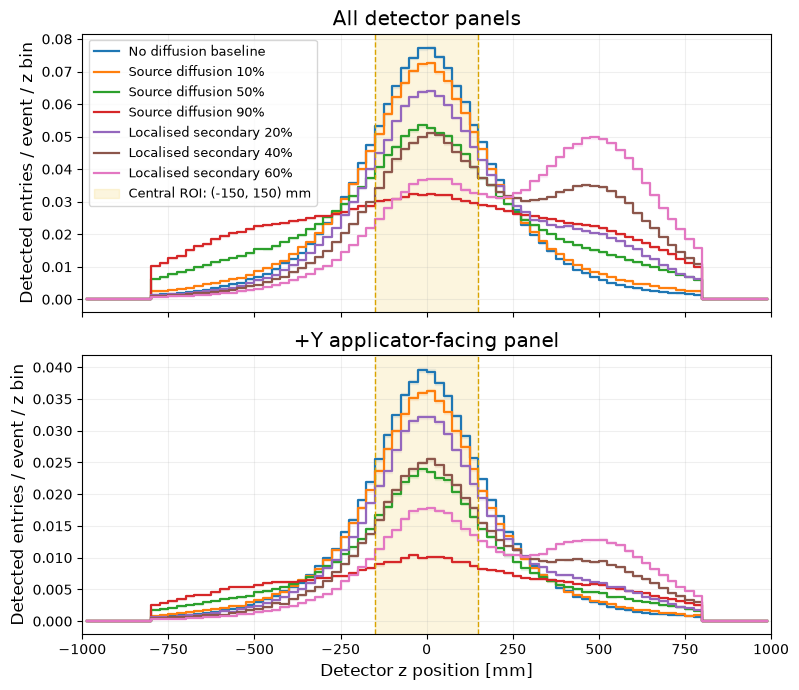

In [ ]:
baseline_posy_central_rate = features_df.loc[
    features_df['case'] == 'baseline', 'PosY_central_rate_per_event'
].mean()

retained_signal_df = features_df[[
    'case', 'rep', 'label', 'diffusion_fraction_true',
    'secondary_fraction_true', 'PosY_central_rate_per_event'
]].copy()
retained_signal_df['retained_signal_fraction'] = (
    retained_signal_df['PosY_central_rate_per_event'] / baseline_posy_central_rate
)
retained_signal_summary_df = (
    retained_signal_df.groupby('case', sort=False)
    .agg(
        label=('label', 'first'),
        retained_signal_fraction_mean=('retained_signal_fraction', 'mean'),
        retained_signal_fraction_sd=('retained_signal_fraction', 'std'),
        n=('retained_signal_fraction', 'size'),
    )
    .reindex([key for key in case_order if key in retained_signal_df['case'].unique()])
    .reset_index()
)
retained_signal_df.to_csv(metrics_output_dir / 'applicator_retained_signal_by_repetition.csv', index=False)
retained_signal_summary_df.to_csv(metrics_output_dir / 'applicator_retained_signal_summary.csv', index=False)
display(retained_signal_summary_df)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
plot_views = [('All', 'Four side panels'), ('PosY', '+Y applicator-facing panel')]
colors = dict(zip(case_order, plt.cm.tab10(np.arange(len(case_order)))))
for ax, (view_name, title) in zip(axes, plot_views):
    for case_key in [key for key in case_order if key in cases]:
        profiles = event_normalized_profiles(case_key, panel_sets[view_name])
        mean_profile, sem_profile = profile_mean_sem(profiles)
        ax.step(z_centers, mean_profile, where='mid', color=colors[case_key],
                linewidth=1.6, label=case_labels[case_key])
        ax.fill_between(z_centers, mean_profile - sem_profile, mean_profile + sem_profile,
                        step='mid', color=colors[case_key], alpha=0.08)
    ax.axvspan(central_z_roi_mm[0], central_z_roi_mm[1], color='#f2c94c', alpha=0.18,
               label='Central ROI: (-150, 150) mm' if view_name == 'All' else None)
    ax.axvline(central_z_roi_mm[0], color='#d9a300', linestyle='--', linewidth=1)
    ax.axvline(central_z_roi_mm[1], color='#d9a300', linestyle='--', linewidth=1)
    ax.set_title(title, fontsize='x-large')
    ax.set_xlim(-1000,1000)
    ax.set_ylabel('Detected entries / event / z bin', fontsize='large')
    ax.grid(alpha=0.20)
axes[0].legend(fontsize=9, ncols=1)
axes[-1].set_xlabel('Detector z position [mm]', fontsize='large')
#fig.suptitle('Profiles used for central signal estimate: ROI -150 to 150 mm', fontsize='x-large')
plt.tight_layout()
save_figure(fig, 'material_signal_central_roi_profiles')
plt.show()


## 4. Far-side leakage ROI diagnostic

This reproduces the visual ROI leakage signal from the poster. The ROI is on the opposite side of the detector from the localised source, so positive excess is a qualitative leakage/diffusion diagnostic. It is not used as the localized-source classifier input in this notebook.


Saved figure: figures/signal_analysis_50reps/poster_03a_leakage_roi_whole_x_panel.png


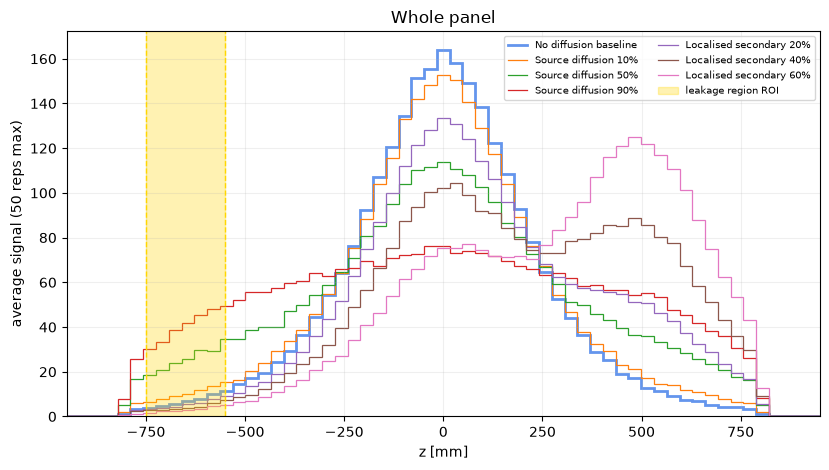

Saved figure: figures/signal_analysis_50reps/poster_03b_leakage_roi_signal.png


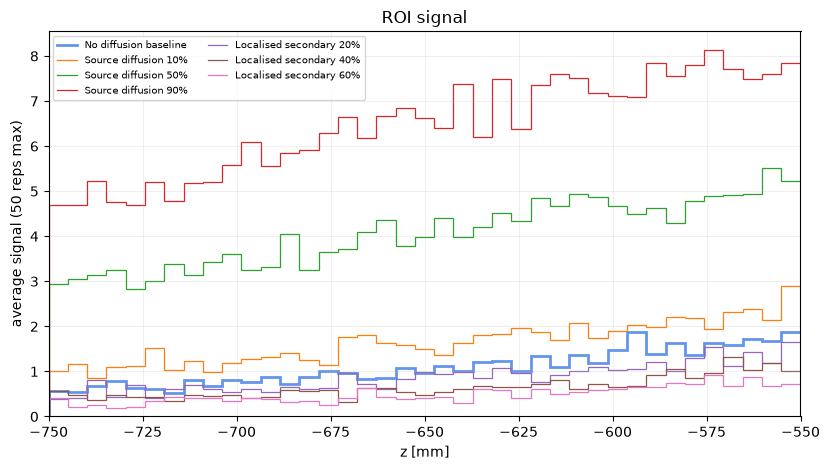

Saved figure: figures/signal_analysis_50reps/poster_03c_leakage_roi_side_by_side.png


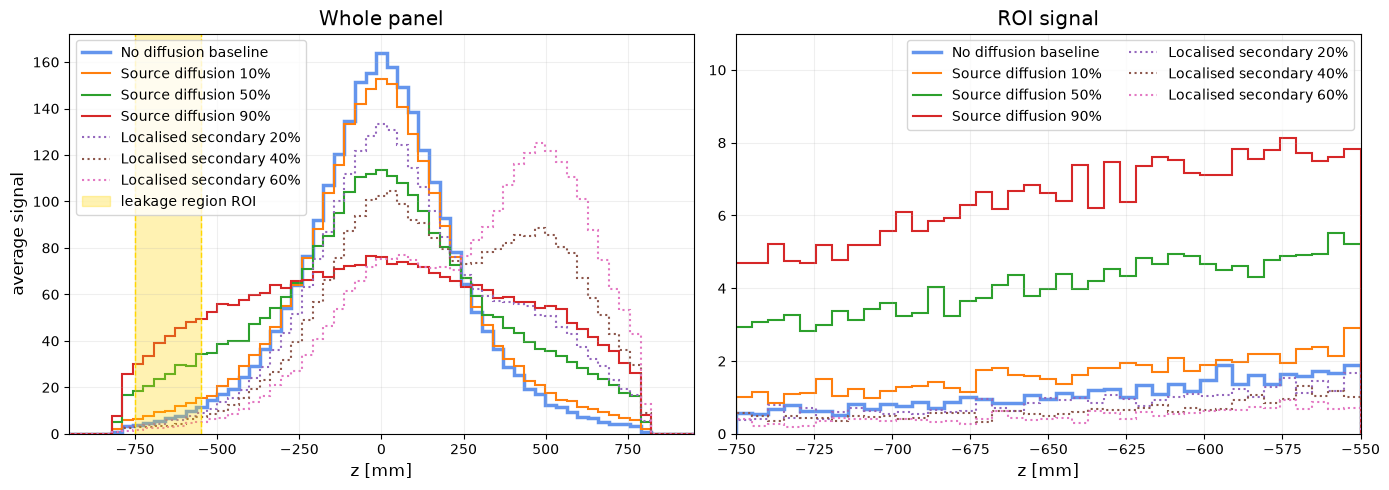

,case,label,panel,roi_z_min_mm,roi_z_max_mm,full_plot_bins,roi_plot_bins,rate_excess_per_event,rate_excess_sem,expected_excess,expected_excess_sem,expected_excess_zscore
0,diff10,Source diffusion 10%,physPhotonDetectorPosX,-750.0,-550.0,59,39,0.002615,0.000164,1.383365e+08,8.663343e+06,15.968027
1,diff50,Source diffusion 50%,physPhotonDetectorPosX,-750.0,-550.0,59,39,0.014524,0.000215,7.683372e+08,1.136492e+07,67.606059
2,diff90,Source diffusion 90%,physPhotonDetectorPosX,-750.0,-550.0,59,39,0.027042,0.000274,1.430574e+09,1.451805e+07,98.537591
3,loc20,Localised secondary 20%,physPhotonDetectorPosX,-750.0,-550.0,59,39,-0.000932,0.000128,-4.928774e+07,6.793025e+06,-7.255640
4,loc40,Localised secondary 40%,physPhotonDetectorPosX,-750.0,-550.0,59,39,-0.001903,0.000126,-1.006980e+08,6.641026e+06,-15.163026
5,loc60,Localised secondary 60%,physPhotonDetectorPosX,-750.0,-550.0,59,39,-0.002645,0.000127,-1.399291e+08,6.729003e+06,-20.794925


In [69]:
def roi_rate_by_rep(case_key, panels, roi, time_limit_s=None):
    z_min, z_max = roi
    values = []
    expected = []
    for rep in cases[case_key]:
        selected = select_entries(rep, panels, time_limit_s=time_limit_s)
        roi_entries = selected[(selected['z_mm'] >= z_min) & (selected['z_mm'] <= z_max)]
        rate = len(roi_entries) / rep['n_events']
        values.append(rate)
        expected.append(len(roi_entries) * rn222_initial_atoms / rep['n_events'])
    return np.asarray(values), np.asarray(expected)


def binned_counts_by_rep(case_key, panels, bins, coord_range=None, time_limit_s=None):
    rep_counts = []
    for rep in cases[case_key]:
        selected = select_entries(rep, panels, time_limit_s=time_limit_s)
        if coord_range is not None:
            z_min, z_max = coord_range
            selected = selected[selected['z_mm'].between(z_min, z_max, inclusive='both')]
        counts, _ = np.histogram(selected['z_mm'], bins=bins)
        rep_counts.append(counts.astype(float))
    return np.vstack(rep_counts)


if candidate_keys_available:
    # Match leakage_region.ipynb: PosX panel, whole-panel x range -950..950 with 60 bin edges,
    # and leakage ROI x range -750..-550 with 40 bin edges.
    leakage_panels = panel_sets['PosX']
    leakage_full_range_mm = (-950.0, 950.0)
    leakage_full_bins = np.linspace(leakage_full_range_mm[0], leakage_full_range_mm[1], 60)
    leakage_roi_bins = np.linspace(leakage_roi_z_mm[0], leakage_roi_z_mm[1], 40)
    leakage_case_order = ['baseline'] + candidate_keys_available
    colors = dict(zip(leakage_case_order, plt.cm.tab10(np.arange(len(leakage_case_order)))))
    if 'baseline' in colors:
        colors['baseline'] = 'cornflowerblue'

    full_counts_by_case = {}
    roi_counts_by_case = {}
    for key in leakage_case_order:
        full_counts_by_case[key] = binned_counts_by_rep(
            key,
            leakage_panels,
            leakage_full_bins,
            coord_range=leakage_full_range_mm,
            time_limit_s=profile_time_limit_s,
        )
        roi_counts_by_case[key] = binned_counts_by_rep(
            key,
            leakage_panels,
            leakage_roi_bins,
            coord_range=leakage_roi_z_mm,
            time_limit_s=profile_time_limit_s,
        )

    # Whole PosX-panel profile with the leakage ROI shaded.
    fig, ax = plt.subplots(figsize=(8.4, 4.8))
    for key in leakage_case_order:
        mean_counts = full_counts_by_case[key].mean(axis=0)
        linewidth = 2.0 if key == 'baseline' else 0.9
        ax.stairs(mean_counts, leakage_full_bins, color=colors[key], linewidth=linewidth, label=case_labels[key])
    ax.axvspan(leakage_roi_z_mm[0], leakage_roi_z_mm[1], color='gold', alpha=0.30, label='leakage region ROI')
    ax.axvline(leakage_roi_z_mm[0], color='gold', linestyle='--', linewidth=1)
    ax.axvline(leakage_roi_z_mm[1], color='gold', linestyle='--', linewidth=1)
    ax.set_xlim(*leakage_full_range_mm)
    ax.set_xlabel('z [mm]')
    ax.set_ylabel(f'average signal ({int(load_summary_df.loaded_repetitions.max())} reps max)')
    ax.set_title('Whole panel')
    ax.grid(alpha=0.20)
    ax.legend(fontsize=7, ncols=2)
    plt.tight_layout()
    save_figure(fig, 'poster_03a_leakage_roi_whole_x_panel')
    plt.show()

    # Zoomed signal inside the leakage ROI, using the same ROI bins as leakage_region.ipynb.
    fig, ax = plt.subplots(figsize=(8.4, 4.8))
    for key in leakage_case_order:
        mean_counts = roi_counts_by_case[key].mean(axis=0)
        linewidth = 2.0 if key == 'baseline' else 0.9
        ax.stairs(mean_counts, leakage_roi_bins, color=colors[key], linewidth=linewidth, label=case_labels[key])
    ax.set_xlim(*leakage_roi_z_mm)
    ax.set_xlabel('z [mm]')
    ax.set_ylabel(f'average signal ({int(load_summary_df.loaded_repetitions.max())} reps max)')
    ax.set_title('ROI signal')
    ax.grid(alpha=0.20)
    ax.legend(fontsize=7, ncols=2)
    plt.tight_layout()
    save_figure(fig, 'poster_03b_leakage_roi_signal')
    plt.show()

    # Poster-style side-by-side leakage diagnostic using the same bins and x limits.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for key in leakage_case_order:
        mean_counts = full_counts_by_case[key].mean(axis=0)
        linewidth = 2.5 if key == 'baseline' else 1.5
        ls = 'dotted' if 'loc' in key else 'solid'
        ax.stairs(mean_counts, leakage_full_bins, color=colors[key], linewidth=linewidth, label=case_labels[key], linestyle=ls)
    ax.axvspan(leakage_roi_z_mm[0], leakage_roi_z_mm[1], color='gold', alpha=0.30, label='leakage region ROI')
    ax.axvline(leakage_roi_z_mm[0], color='gold', linestyle='--', linewidth=1)
    ax.axvline(leakage_roi_z_mm[1], color='gold', linestyle='--', linewidth=1)
    ax.set_xlim(*leakage_full_range_mm)
    ax.set_xlabel('z [mm]',fontsize='large')
    ax.set_ylabel(f'average signal',fontsize='large')
    ax.set_title('Whole panel',fontsize='x-large')
    ax.grid(alpha=0.20)
    ax.legend(fontsize='medium', ncols=1)

    ax = axes[1]
    for key in leakage_case_order:
        mean_counts = roi_counts_by_case[key].mean(axis=0)
        linewidth = 2.5 if key == 'baseline' else 1.5
        ls = 'dotted' if 'loc' in key else 'solid'
        ax.stairs(mean_counts, leakage_roi_bins, color=colors[key], linewidth=linewidth, label=case_labels[key], linestyle=ls)
    ax.set_xlim(*leakage_roi_z_mm)
    ax.set_ylim(0, 11)
    ax.set_xlabel('z [mm]', fontsize='large')
    ax.set_title('ROI signal', fontsize='x-large')
    ax.grid(alpha=0.20)
    ax.legend(fontsize='medium', ncols=2)

    plt.tight_layout()
    save_figure(fig, 'poster_03c_leakage_roi_side_by_side')
    plt.show()

    leakage_rows = []
    baseline_rates, baseline_expected = roi_rate_by_rep('baseline', leakage_panels, leakage_roi_z_mm, time_limit_s=profile_time_limit_s)
    for key in candidate_keys_available:
        rates, expected = roi_rate_by_rep(key, leakage_panels, leakage_roi_z_mm, time_limit_s=profile_time_limit_s)
        leakage_rows.append({
            'case': key,
            'label': case_labels[key],
            'panel': 'physPhotonDetectorPosX',
            'roi_z_min_mm': leakage_roi_z_mm[0],
            'roi_z_max_mm': leakage_roi_z_mm[1],
            'full_plot_bins': len(leakage_full_bins) - 1,
            'roi_plot_bins': len(leakage_roi_bins) - 1,
            'rate_excess_per_event': rates.mean() - baseline_rates.mean(),
            'rate_excess_sem': np.sqrt(sem(rates) ** 2 + sem(baseline_rates) ** 2),
            'expected_excess': expected.mean() - baseline_expected.mean(),
            'expected_excess_sem': np.sqrt(sem(expected) ** 2 + sem(baseline_expected) ** 2),
        })
    leakage_summary_df = pd.DataFrame(leakage_rows)
    leakage_summary_df['expected_excess_zscore'] = leakage_summary_df['expected_excess'] / leakage_summary_df['expected_excess_sem'].replace(0, np.nan)
    leakage_summary_df.to_csv(metrics_output_dir / 'leakage_roi_diagnostic_summary.csv', index=False)
    display(leakage_summary_df)
else:
    print('Leakage ROI diagnostic skipped until candidate outputs exist.')


## 5. Localised-source search ROI and residual position

The localised-source search uses the overlapping/displaced-source ROI around the simulated secondary source (`250 <= z <= 750 mm`). This is the ROI used for localised-source evidence, and it is separate from the far-side leakage ROI. The plots below show the ROI signal, secondary-source probability, and residual-position distributions for the localised cases.


LOO accuracy: 1.000
LOO ROC AUC: 1.000


,pred_no_secondary,pred_secondary
true_no_secondary,200,0
true_secondary,0,150


,case,label,true_secondary,true_secondary_fraction,secondary_probability_mean,secondary_probability_sd,predicted_positive_fraction,secondary_roi_rate_mean,secondary_roi_rate_sd,secondary_roi_excess_mean,secondary_roi_excess_sd,zhat_xsum_mean_mm,zhat_xsum_sd_mm,zhat_ysum_mean_mm,zhat_ysum_sd_mm,zhat_combined_mean_mm,zhat_combined_sd_mm,position_residual_mean_mm,position_residual_sd_mm,inside_source_extent_fraction,distance_outside_source_extent_mean_mm,distance_outside_source_extent_max_mm
0,baseline,No diffusion baseline,0,0.0,0.001773,7.621842e-04,0.0,0.080556,0.002836,1.942890e-18,0.002836,2.136069,54.884767,2.845236,53.893838,2.490652,37.282504,NaN,NaN,0.00,472.509348,564.197794
1,diff10,Source diffusion 10%,0,0.0,0.001120,6.019400e-04,0.0,0.093406,0.003273,1.285026e-02,0.003273,-1.790095,56.866266,-12.778029,50.199378,-7.284062,38.207159,NaN,NaN,0.00,482.284062,556.796866
2,diff50,Source diffusion 50%,0,0.0,0.000826,6.632035e-04,0.0,0.148413,0.004662,6.785744e-02,0.004662,-0.731515,20.953114,1.191084,22.034652,0.229784,15.877809,NaN,NaN,0.00,474.770216,526.727411
3,diff90,Source diffusion 90%,0,0.0,0.000351,4.447717e-04,0.0,0.208232,0.006334,1.276762e-01,0.006334,1.716108,19.095708,-3.553597,18.109515,-0.918744,14.743141,NaN,NaN,0.00,475.918744,504.361057
4,loc20,Localised secondary 20%,1,20.0,0.996997,1.436964e-03,1.0,0.178812,0.004500,9.825689e-02,0.004500,512.958027,8.515461,518.418691,10.384232,515.688359,6.586309,15.688359,6.586309,0.92,0.158268,4.951659
5,loc40,Localised secondary 40%,1,40.0,1.000000,7.623565e-08,1.0,0.281916,0.005113,2.013606e-01,0.005113,524.523857,4.924208,532.090639,4.555443,528.307248,3.651113,28.307248,3.651113,0.18,3.692070,10.206376
6,loc60,Localised secondary 60%,1,60.0,1.000000,3.242474e-12,1.0,0.387531,0.006329,3.069752e-01,0.006329,527.656445,3.162925,533.188186,2.729384,530.422315,2.103069,30.422315,2.103069,0.00,5.422315,9.544267


Saved figure: figures/signal_analysis_50reps/poster_04a_secondary_source_roi_detection_and_location.png


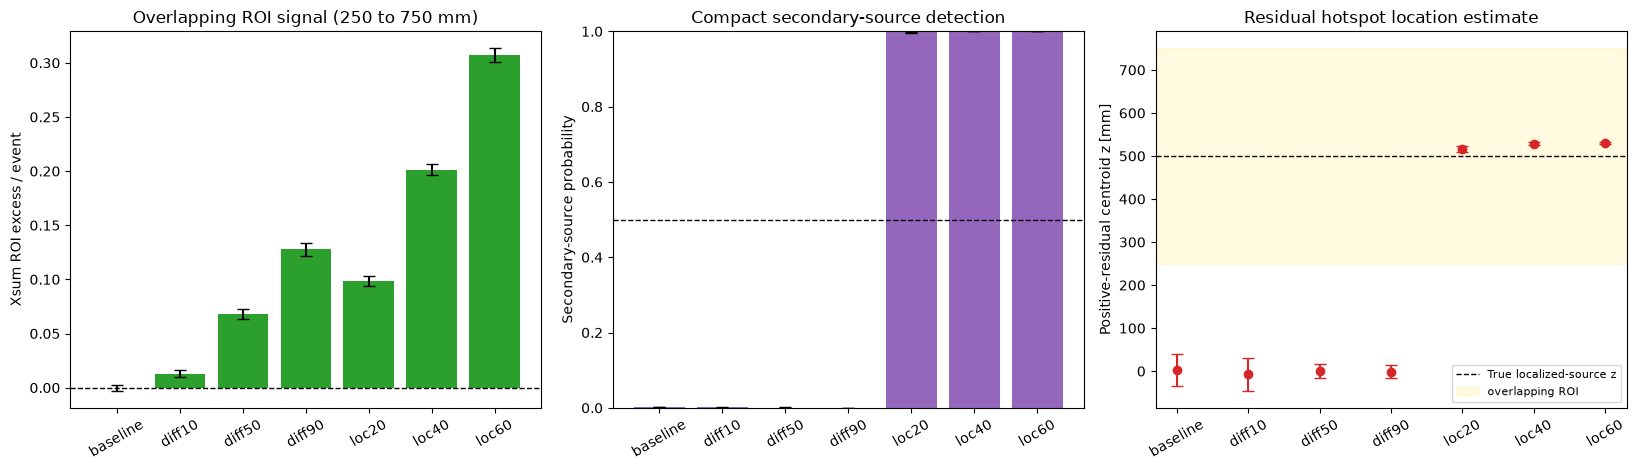

Saved figure: figures/signal_analysis_50reps/poster_04b_localised_source_position_residuals.png


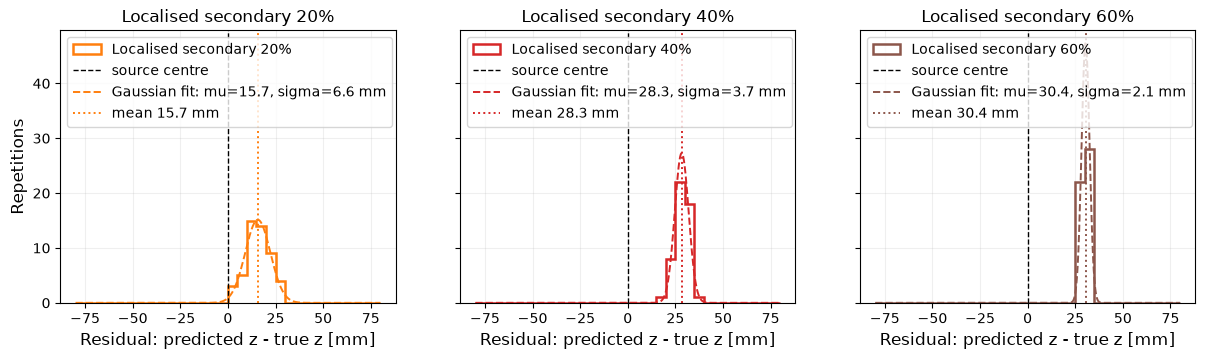

Saved figure: figures/signal_analysis_50reps/poster_04c_localised_source_extent_aware_position.png


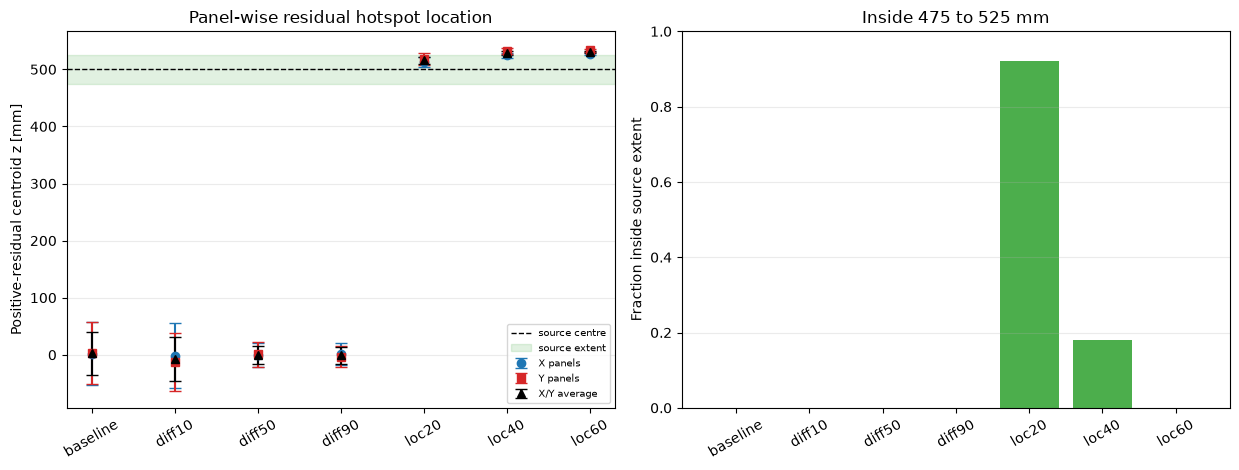

Saved figure: figures/signal_analysis_50reps/poster_04d_localised_source_distance_outside_extent.png


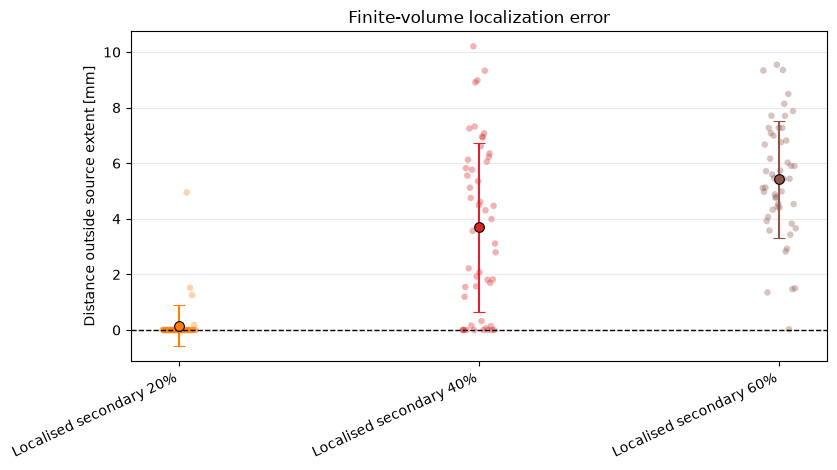

In [70]:
available_localised_cases = [key for key in ['loc20', 'loc40', 'loc60'] if key in set(features_df['case'])]
if 'baseline' in set(features_df['case']) and available_localised_cases:
    secondary_feature_cols = []
    secondary_feature_cols += columns_matching(features_df, prefixes=('PosY_', 'NegY_', 'Ysum_', 'Xsum_', 'All_'), contains=('residual_bin_',))
    secondary_feature_cols += [
        col for col in features_df.columns
        if any(col.endswith(suffix) for suffix in [
            'positive_residual_per_event', 'positive_residual_centroid_z_mm',
            'positive_residual_peak_z_mm', 'positive_residual_peak_per_event',
            'secondary_roi_rate_per_event', 'residual_l1_per_event', 'z_std_mm', 'z_q80_width_mm'
        ])
    ]
    secondary_feature_cols += ['Y_panel_asymmetry', 'X_panel_asymmetry', 'Y_to_X_rate_ratio', 'detected_rate_all_per_event']
    secondary_feature_cols = sorted(set(secondary_feature_cols))

    sec_df = features_df[features_df['case'].isin([key for key in secondary_training_cases if key in features_df['case'].unique()])].copy()
    X_sec = sec_df[secondary_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    y_sec = sec_df['secondary_present_true'].to_numpy(dtype=int)

    sec_prob = np.zeros(len(sec_df))
    sec_pred = np.zeros(len(sec_df), dtype=int)
    for train_idx, test_idx in LeaveOneOut().split(X_sec):
        clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', C=0.5, max_iter=2000))
        clf.fit(X_sec.iloc[train_idx], y_sec[train_idx])
        sec_prob[test_idx] = clf.predict_proba(X_sec.iloc[test_idx])[:, 1]
        sec_pred[test_idx] = (sec_prob[test_idx] >= 0.5).astype(int)

    sec_df['secondary_probability_cv'] = sec_prob
    sec_df['secondary_present_pred_cv'] = sec_pred
    localized_source_half_extent_mm = 25.0
    localized_source_z_min_mm = 500.0 - localized_source_half_extent_mm
    localized_source_z_max_mm = 500.0 + localized_source_half_extent_mm

    sec_df['zhat_xsum_z_mm'] = sec_df['Xsum_positive_residual_centroid_z_mm']
    sec_df['zhat_ysum_z_mm'] = sec_df['Ysum_positive_residual_centroid_z_mm']
    sec_df['zhat_combined_z_mm'] = sec_df[['zhat_xsum_z_mm', 'zhat_ysum_z_mm']].mean(axis=1)
    sec_df['position_residual_mm'] = sec_df['zhat_combined_z_mm'] - sec_df['secondary_z_mm_true']
    sec_df['xsum_position_residual_mm'] = sec_df['zhat_xsum_z_mm'] - sec_df['secondary_z_mm_true']
    sec_df['ysum_position_residual_mm'] = sec_df['zhat_ysum_z_mm'] - sec_df['secondary_z_mm_true']
    sec_df['inside_localized_source_extent'] = sec_df['zhat_combined_z_mm'].between(localized_source_z_min_mm, localized_source_z_max_mm, inclusive='both')
    sec_df['distance_outside_source_extent_mm'] = (
        (localized_source_z_min_mm - sec_df['zhat_combined_z_mm']).clip(lower=0)
        + (sec_df['zhat_combined_z_mm'] - localized_source_z_max_mm).clip(lower=0)
    )

    baseline_secondary_roi = sec_df.loc[sec_df['case'] == 'baseline', 'Xsum_secondary_roi_rate_per_event'].to_numpy(dtype=float)
    sec_df['secondary_roi_excess_per_event'] = sec_df['Xsum_secondary_roi_rate_per_event'] - np.nanmean(baseline_secondary_roi)

    print(f"LOO accuracy: {accuracy_score(y_sec, sec_pred):.3f}")
    if len(np.unique(y_sec)) > 1:
        print(f"LOO ROC AUC: {roc_auc_score(y_sec, sec_prob):.3f}")
    display(pd.DataFrame(confusion_matrix(y_sec, sec_pred), index=['true_no_secondary', 'true_secondary'], columns=['pred_no_secondary', 'pred_secondary']))

    secondary_summary_df = sec_df.groupby('case', sort=False).agg(
        label=('label', 'first'),
        true_secondary=('secondary_present_true', 'first'),
        true_secondary_fraction=('secondary_fraction_true', 'first'),
        secondary_probability_mean=('secondary_probability_cv', 'mean'),
        secondary_probability_sd=('secondary_probability_cv', 'std'),
        predicted_positive_fraction=('secondary_present_pred_cv', 'mean'),
        secondary_roi_rate_mean=('Xsum_secondary_roi_rate_per_event', 'mean'),
        secondary_roi_rate_sd=('Xsum_secondary_roi_rate_per_event', 'std'),
        secondary_roi_excess_mean=('secondary_roi_excess_per_event', 'mean'),
        secondary_roi_excess_sd=('secondary_roi_excess_per_event', 'std'),
        zhat_xsum_mean_mm=('zhat_xsum_z_mm', 'mean'),
        zhat_xsum_sd_mm=('zhat_xsum_z_mm', 'std'),
        zhat_ysum_mean_mm=('zhat_ysum_z_mm', 'mean'),
        zhat_ysum_sd_mm=('zhat_ysum_z_mm', 'std'),
        zhat_combined_mean_mm=('zhat_combined_z_mm', 'mean'),
        zhat_combined_sd_mm=('zhat_combined_z_mm', 'std'),
        position_residual_mean_mm=('position_residual_mm', 'mean'),
        position_residual_sd_mm=('position_residual_mm', 'std'),
        inside_source_extent_fraction=('inside_localized_source_extent', 'mean'),
        distance_outside_source_extent_mean_mm=('distance_outside_source_extent_mm', 'mean'),
        distance_outside_source_extent_max_mm=('distance_outside_source_extent_mm', 'max'),
    ).reindex([key for key in case_order if key in sec_df['case'].unique()]).reset_index()
    display(secondary_summary_df)
    sec_df.to_csv(metrics_output_dir / 'secondary_source_cv_predictions.csv', index=False)
    secondary_summary_df.to_csv(metrics_output_dir / 'secondary_source_summary.csv', index=False)

    plot_summary = secondary_summary_df.dropna(subset=['case'])
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

    axes[0].bar(plot_summary['case'], plot_summary['secondary_roi_excess_mean'], yerr=plot_summary['secondary_roi_excess_sd'], capsize=4, color='tab:green')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_ylabel('Xsum ROI excess / event')
    axes[0].set_title(f'Overlapping ROI signal ({secondary_search_z_roi_mm[0]:.0f} to {secondary_search_z_roi_mm[1]:.0f} mm)')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(plot_summary['case'], plot_summary['secondary_probability_mean'], yerr=plot_summary['secondary_probability_sd'], capsize=4, color='tab:purple')
    axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('Secondary-source probability')
    axes[1].set_title('Compact secondary-source detection')
    axes[1].tick_params(axis='x', rotation=30)

    axes[2].errorbar(plot_summary['case'], plot_summary['zhat_combined_mean_mm'], yerr=plot_summary['zhat_combined_sd_mm'], fmt='o', capsize=4, color='tab:red')
    axes[2].axhline(500, color='black', linestyle='--', linewidth=1, label='True localized-source z')
    axes[2].axhspan(secondary_search_z_roi_mm[0], secondary_search_z_roi_mm[1], color='gold', alpha=0.12, label='overlapping ROI')
    axes[2].set_ylabel('Positive-residual centroid z [mm]')
    axes[2].set_title('Residual hotspot location estimate')
    axes[2].tick_params(axis='x', rotation=30)
    axes[2].legend(fontsize=8)
    plt.tight_layout()
    save_figure(fig, 'poster_04a_secondary_source_roi_detection_and_location')
    plt.show()

    loc_cases = [key for key in available_localised_cases if key in sec_df['case'].unique()]
    fig, axes = plt.subplots(1, len(loc_cases), figsize=(4.2 * len(loc_cases), 3.7), sharey=True)
    if len(loc_cases) == 1:
        axes = [axes]
    loc_colors = dict(zip(loc_cases, ['tab:orange', 'tab:red', 'tab:brown']))
    residual_bins = np.linspace(-80, 80, 33)
    residual_bin_width = residual_bins[1] - residual_bins[0]
    for ax, key in zip(axes, loc_cases):
        vals = sec_df.loc[sec_df['case'] == key, 'position_residual_mm'].dropna().to_numpy(dtype=float)
        counts, _, _ = ax.hist(vals, bins=residual_bins, histtype='step', linewidth=1.8, color=loc_colors[key], label=case_labels[key])
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='source centre')
        if len(vals) >= 2:
            mu = float(np.nanmean(vals))
            sigma = float(np.nanstd(vals, ddof=1))
            if np.isfinite(sigma) and sigma > 0:
                x_fit = np.linspace(residual_bins[0], residual_bins[-1], 400)
                gaussian_counts = (
                    len(vals)
                    * residual_bin_width
                    * np.exp(-0.5 * ((x_fit - mu) / sigma) ** 2)
                    / (sigma * np.sqrt(2 * np.pi))
                )
                ax.plot(x_fit, gaussian_counts, color=loc_colors[key], linestyle='--', linewidth=1.4, label=f'Gaussian fit: mu={mu:.1f}, sigma={sigma:.1f} mm')
            ax.axvline(mu, color=loc_colors[key], linestyle=':', linewidth=1.4, label=f'mean {mu:.1f} mm')
        ax.set_title(case_labels[key], fontsize='large')
        ax.set_xlabel('Residual: predicted z - true z [mm]', fontsize='large')
        ax.grid(alpha=0.20)
        ax.legend(fontsize='medium', loc='upper left')
    axes[0].set_ylabel('Repetitions', fontsize='large')
    #fig.suptitle('Localised-source position residuals by source fraction', y=1.03, fontsize='x-large')
    plt.tight_layout()
    save_figure(fig, 'poster_04b_localised_source_position_residuals')
    plt.show()


    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
    ax = axes[0]
    ax.errorbar(plot_summary['case'], plot_summary['zhat_xsum_mean_mm'], yerr=plot_summary['zhat_xsum_sd_mm'], fmt='o', capsize=4, color='tab:blue', label='X panels')
    ax.errorbar(plot_summary['case'], plot_summary['zhat_ysum_mean_mm'], yerr=plot_summary['zhat_ysum_sd_mm'], fmt='s', capsize=4, color='tab:red', label='Y panels')
    ax.errorbar(plot_summary['case'], plot_summary['zhat_combined_mean_mm'], yerr=plot_summary['zhat_combined_sd_mm'], fmt='^', capsize=4, color='black', label='X/Y average')
    ax.axhline(500, color='black', linestyle='--', linewidth=1, label='source centre')
    ax.axhspan(localized_source_z_min_mm, localized_source_z_max_mm, color='tab:green', alpha=0.14, label='source extent')
    ax.set_ylabel('Positive-residual centroid z [mm]')
    ax.set_title('Panel-wise residual hotspot location')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=7)

    ax = axes[1]
    ax.bar(plot_summary['case'], plot_summary['inside_source_extent_fraction'], color='tab:green', alpha=0.85)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Fraction inside source extent')
    ax.set_title(f'Inside {localized_source_z_min_mm:.0f} to {localized_source_z_max_mm:.0f} mm')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)

    plt.tight_layout()
    save_figure(fig, 'poster_04c_localised_source_extent_aware_position')
    plt.show()


    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    x_positions = np.arange(len(loc_cases), dtype=float)
    for i, key in enumerate(loc_cases):
        values = sec_df.loc[sec_df['case'] == key, 'distance_outside_source_extent_mm'].dropna().to_numpy(dtype=float)
        jitter = np.linspace(-0.055, 0.055, len(values)) if len(values) > 1 else np.array([0.0])
        color = loc_colors[key]
        ax.scatter(i + jitter, values, s=22, color=color, alpha=0.35, edgecolor='none')
        ax.errorbar(i, np.nanmean(values), yerr=np.nanstd(values, ddof=1), fmt='o', ms=7, color=color, mec='black', mew=0.8, capsize=4)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([case_labels[key] for key in loc_cases], rotation=25, ha='right')
    ax.set_ylabel('Distance outside source extent [mm]')
    ax.set_title('Finite-volume localization error')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    save_figure(fig, 'poster_04d_localised_source_distance_outside_extent')
    plt.show()
else:
    print('Localised-source search skipped until at least one localized candidate output is available.')


## 6. Time-window detectability for all cases

Hits are accumulated with increasing cumulative time windows and baseline-subtracted across the full `PosX + NegX` profile. No ROI is used in this section. Detectability is summarised from the whole residual profile using the maximum absolute residual Z-score and integrated absolute residual.

The section saves a summary table and one cumulative residual-profile plot for every available candidate case.


In [47]:
time_profile_rows = []
for key in candidate_keys_available:
    for time_label, time_limit_s in time_thresholds:
        result = activity_residual(key, panel_sets['Xsum'], time_limit_s=time_limit_s)
        residual = result['residual']
        sigma = result['sigma']
        zscore = np.divide(residual, sigma, out=np.zeros_like(residual, dtype=float), where=sigma > 0)
        strongest_idx = int(np.nanargmax(np.abs(zscore))) if len(zscore) else 0
        time_profile_rows.append({
            'case': key,
            'label': case_labels[key],
            'time_label': time_label,
            'time_s': time_limit_s,
            'max_abs_zscore': float(np.nanmax(np.abs(zscore))) if len(zscore) else np.nan,
            'strongest_z_mm': float(z_centers[strongest_idx]) if len(zscore) else np.nan,
            'integrated_expected_residual': float(np.nansum(residual)),
            'integrated_abs_expected_residual': float(np.nansum(np.abs(residual))),
            'max_positive_expected_residual': float(np.nanmax(residual)) if len(residual) else np.nan,
            'max_negative_expected_residual': float(np.nanmin(residual)) if len(residual) else np.nan,
            'detected_3sigma_profile_wide': bool(np.nanmax(np.abs(zscore)) >= 3) if len(zscore) else False,
        })

time_profile_detectability_df = pd.DataFrame(time_profile_rows)
first_detect_rows = []
if not time_profile_detectability_df.empty:
    for key, group in time_profile_detectability_df.sort_values('time_s').groupby('case'):
        detected = group[group['detected_3sigma_profile_wide']]
        first = detected.iloc[0] if not detected.empty else None
        first_detect_rows.append({
            'case': key,
            'label': case_labels[key],
            'first_detectable_time_label': first['time_label'] if first is not None else None,
            'first_detectable_time_s': first['time_s'] if first is not None else np.nan,
            'max_abs_zscore': group['max_abs_zscore'].max(),
            'time_at_max_abs_zscore': group.loc[group['max_abs_zscore'].idxmax(), 'time_label'],
        })
first_detectability_df = pd.DataFrame(first_detect_rows)
time_profile_detectability_df.to_csv(metrics_output_dir / 'time_window_profile_detectability.csv', index=False)
first_detectability_df.to_csv(metrics_output_dir / 'time_window_first_profile_detectability_summary.csv', index=False)
display(first_detectability_df)


,case,label,first_detectable_time_label,first_detectable_time_s,max_abs_zscore,time_at_max_abs_zscore
0,diff10,Source diffusion 10%,6 h,21600,6.806156,2 d
1,diff50,Source diffusion 50%,2 h,7200,19.659504,2 d
2,diff90,Source diffusion 90%,1 h,3600,30.091375,2 d
3,loc20,Localised secondary 20%,2 h,7200,25.916254,2 d
4,loc40,Localised secondary 40%,1 h,3600,39.851857,2 d
5,loc60,Localised secondary 60%,1 h,3600,53.292636,2 d


Saved figure: figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_diff10.png


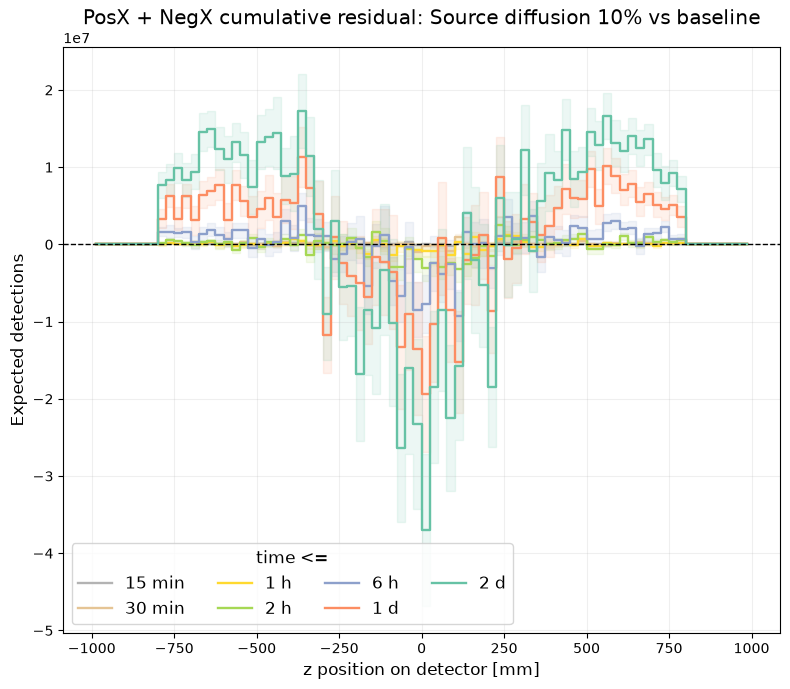

Saved figure: figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_diff50.png


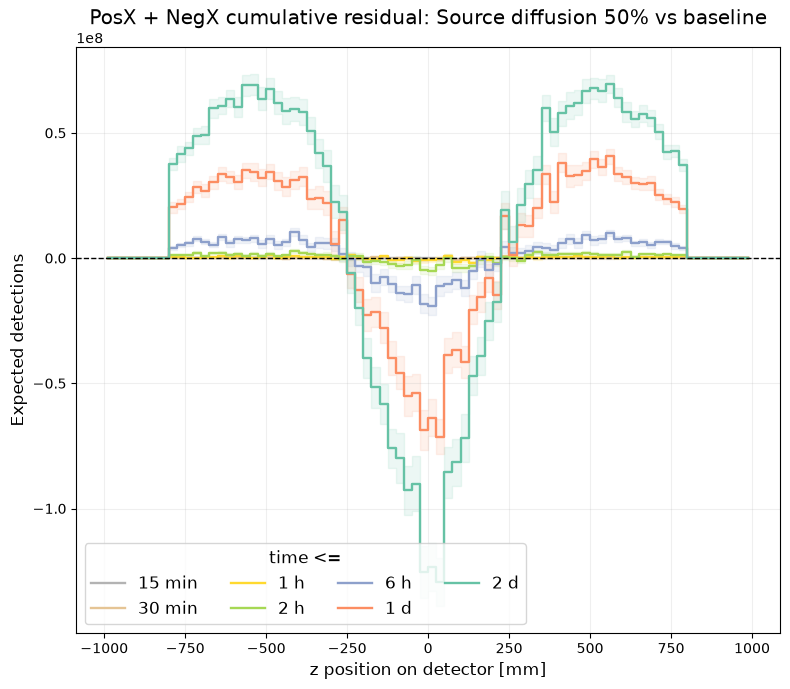

Saved figure: figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_diff90.png


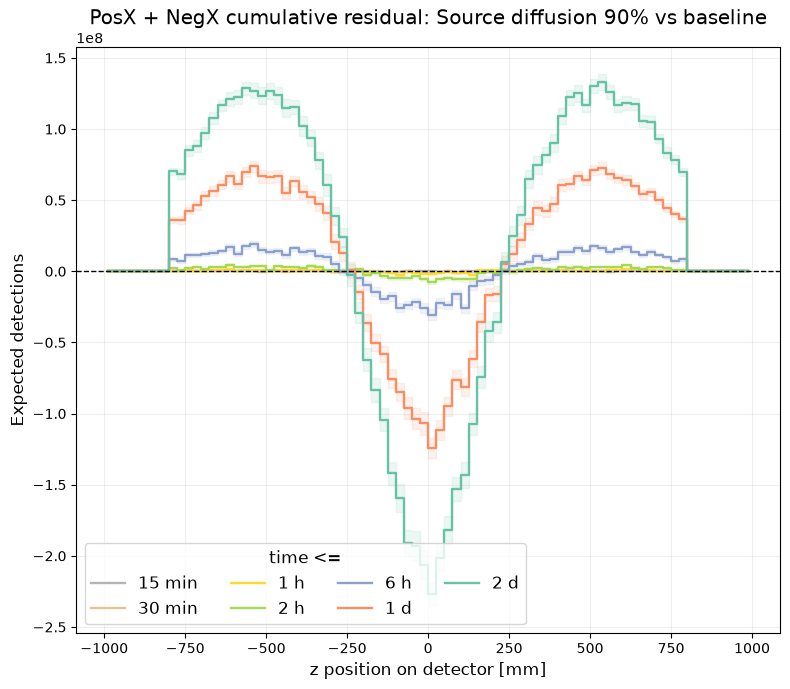

Saved figure: figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_loc20.png


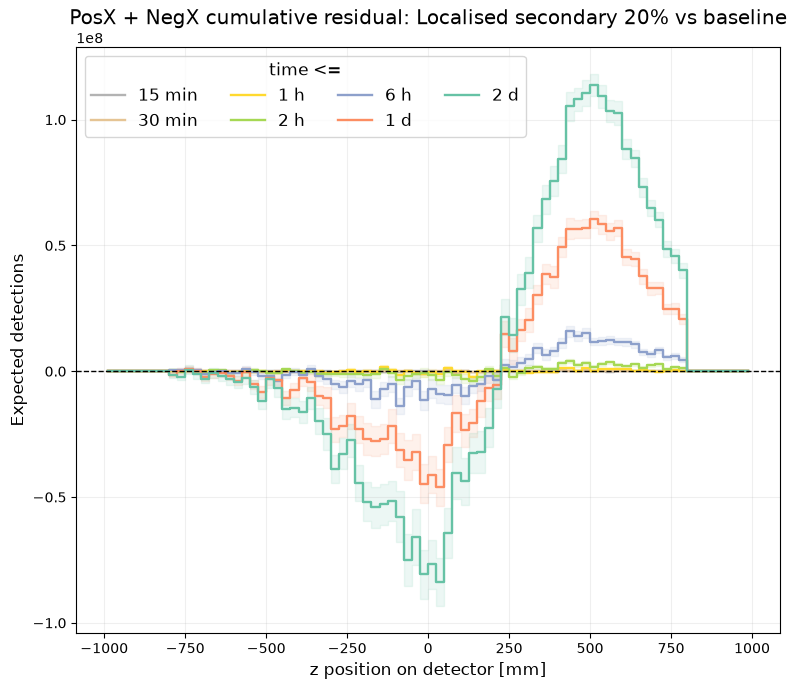

Saved figure: figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_loc40.png


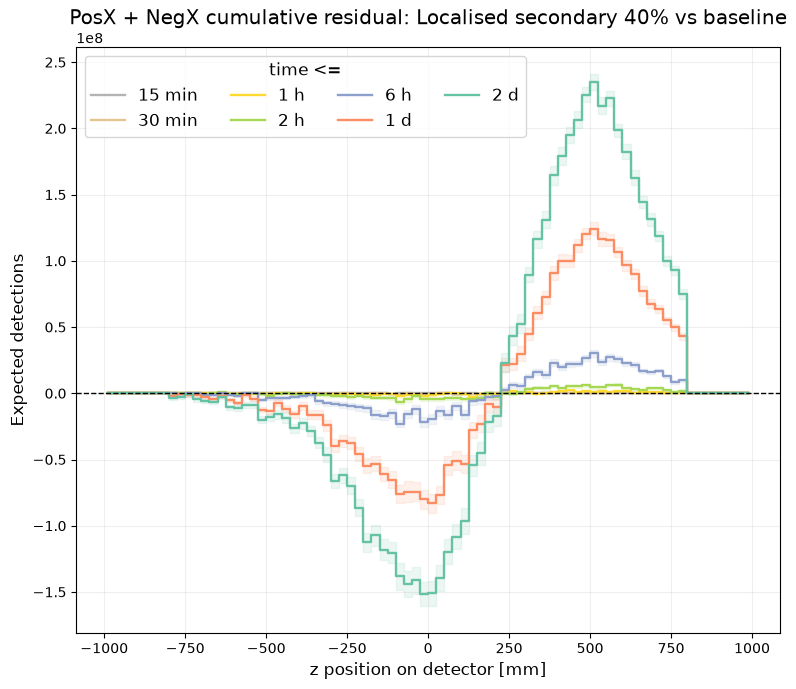

Saved figure: figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_loc60.png


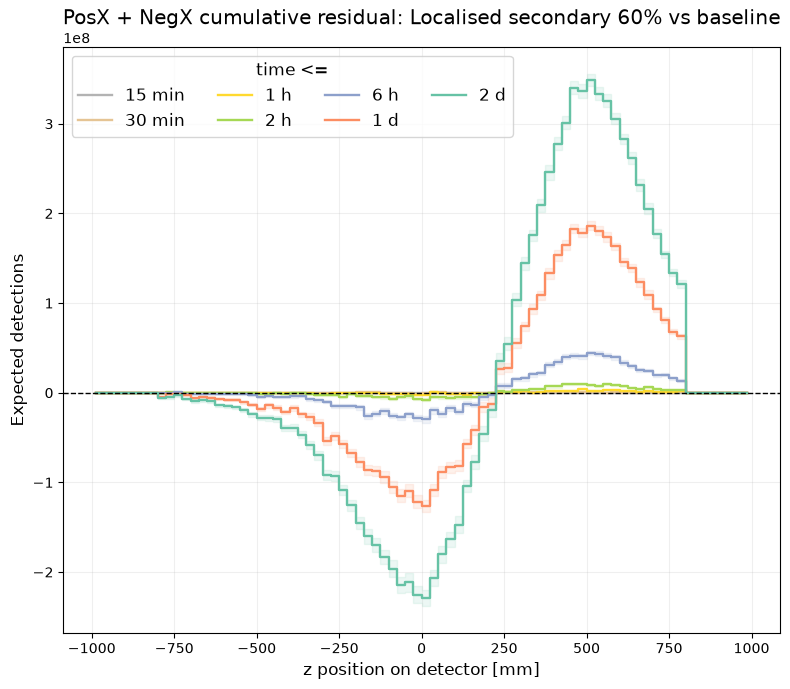

In [48]:
if candidate_keys_available:
    time_colors = dict(zip([label for label, _ in time_thresholds], plt.cm.Set2_r(np.linspace(0.05, 0.95, len(time_thresholds)))))
    for key in candidate_keys_available:
        fig, ax = plt.subplots(figsize=(8, 7))
        for time_label, time_limit_s in time_thresholds:
            result = activity_residual(key, panel_sets['Xsum'], time_limit_s=time_limit_s)
            residual = result['residual']
            sigma = result['sigma']
            color = time_colors[time_label]
            ax.step(z_centers, residual, where='mid', color=color, linewidth=1.7, label=time_label)
            ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', color=color, alpha=0.12)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel('z position on detector [mm]', fontsize='large')
        ax.set_ylabel('Expected detections',fontsize='large')
        ax.set_title(f'PosX + NegX cumulative residual: {case_labels[key]} vs baseline',fontsize='x-large')
        ax.grid(alpha=0.20)
        ax.legend(title='time <=', fontsize='large', ncols=4, title_fontsize='large')
        plt.tight_layout()
        save_figure(fig, f'poster_05_time_window_residual_profiles_{key}')
        plt.show()
else:
    print('Time-window plots skipped until candidate outputs exist.')


### Paired diffusion and localised-source time profiles

This compact two-panel version contrasts the spatial signatures of 50% broad diffusion and 40% localised displacement for use in the paper.


Saved figure: figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_diff50_loc40.png


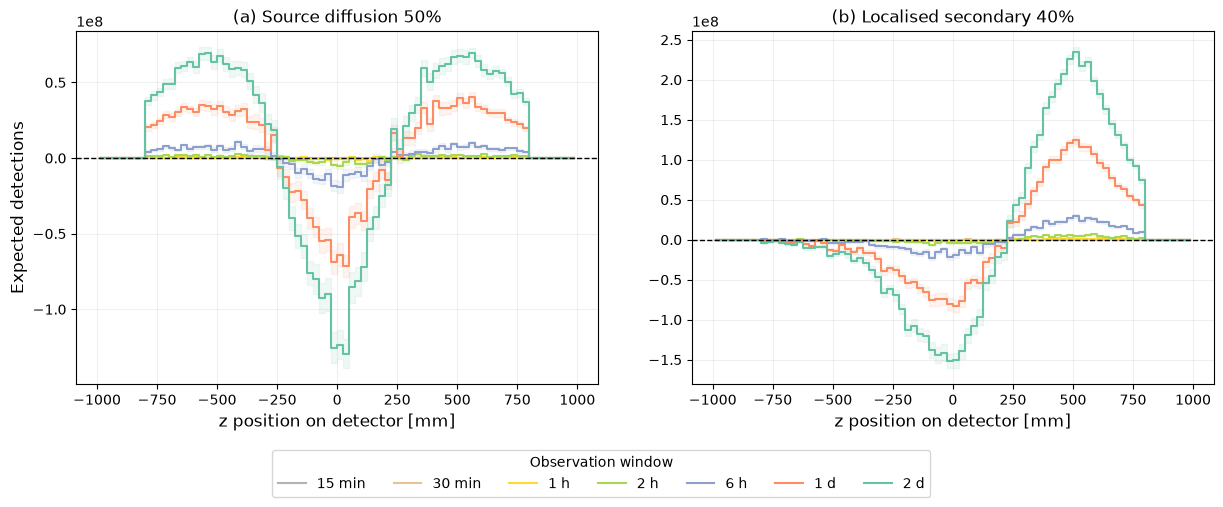

In [49]:
paired_time_cases = ['diff50', 'loc40']
if all(key in candidate_keys_available for key in paired_time_cases):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), sharex=True)
    for ax, key, panel_label in zip(axes, paired_time_cases, ['(a)', '(b)']):
        for time_label, time_limit_s in time_thresholds:
            result = activity_residual(key, panel_sets['Xsum'], time_limit_s=time_limit_s)
            residual = result['residual']
            sigma = result['sigma']
            color = time_colors[time_label]
            ax.step(z_centers, residual, where='mid', color=color, linewidth=1.5, label=time_label)
            ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', color=color, alpha=0.10)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel('z position on detector [mm]', fontsize='large')
        ax.set_title(f'{panel_label} {case_labels[key]}', fontsize='large')
        ax.grid(alpha=0.20)
    axes[0].set_ylabel('Expected detections', fontsize='large')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Observation window', loc='lower center',
               bbox_to_anchor=(0.5, -0.01), ncols=len(time_thresholds),
               fontsize='medium', title_fontsize='medium')
    fig.subplots_adjust(left=0.08, right=0.99, top=0.90, bottom=0.22, wspace=0.18)
    save_figure(fig, 'poster_05_time_window_residual_profiles_diff50_loc40')
    plt.show()
else:
    missing = [key for key in paired_time_cases if key not in candidate_keys_available]
    print(f'Paired time-window plot skipped; missing cases: {missing}')


## Compact poster-output index

The cells above save the poster-relevant figures to `figures/signal_analysis_50reps` and supporting tables to `outputs/signal_analysis_50reps`. Re-run the full notebook after the 50-repetition job finishes; the loader will automatically pick up completed photon-boundary outputs from the manifest.


In [50]:
figure_index = sorted(figure_output_dir.glob('*.png'))
metrics_index = sorted(metrics_output_dir.glob('*.csv'))
print('Saved figures:')
for path in figure_index:
    print(f'  {path}')
print('\nSaved tables:')
for path in metrics_index:
    print(f'  {path}')


Saved figures:
  figures/signal_analysis_50reps/material_signal_central_roi_profiles.png
  figures/signal_analysis_50reps/poster_01_baseline_subtracted_profiles_xsum_all_cases.png
  figures/signal_analysis_50reps/poster_02_diffusion_fraction_cv_prediction.png
  figures/signal_analysis_50reps/poster_03a_leakage_roi_whole_x_panel.png
  figures/signal_analysis_50reps/poster_03b_leakage_roi_signal.png
  figures/signal_analysis_50reps/poster_03c_leakage_roi_side_by_side.png
  figures/signal_analysis_50reps/poster_04a_secondary_source_roi_detection_and_location.png
  figures/signal_analysis_50reps/poster_04b_localised_source_position_residuals.png
  figures/signal_analysis_50reps/poster_04c_localised_source_extent_aware_position.png
  figures/signal_analysis_50reps/poster_04d_localised_source_distance_outside_extent.png
  figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_diff10.png
  figures/signal_analysis_50reps/poster_05_time_window_residual_profiles_diff50.png
  figu